# Fast enough to play with

Notebook 14 got the model right and the arithmetic slow. Carrying a belief over four
parameters -- $\sigma_x$, $\sigma_y$, $b_x$, $b_y$ -- on a product grid costs about four
seconds a dart, which is not usable between throws at all: a fifth parameter multiplies it
again, and a phone is not a workstation.

Profiling that first, because it decides what the fix has to be. It splits in two, and
**only one half is the belief**:

| | cost | what it is |
|---|---|---|
| belief update | ~550 ms | the likelihood at every grid point: 8,019 points x the pixels of the observed score |
| recommendation | 4–280 ms | averaging Q over 25 solved covariances x 99 biases x 8,109 candidate aim points, over however many cells still carry weight |

That second row is why "just use a Laplace approximation" is the wrong prescription. A
smarter *representation* of the posterior speeds up the first half and does nothing for the
second, which is a sum over however many points the belief is carried on.

Both halves have the same cure: **carry the belief on a small support set instead of a
grid**. Then the update is over a few hundred points rather than eight thousand, *and* the
Q-average has only a few dozen distinct terms once particles agreeing on a covariance and a
shift are merged.

`ParticleThrowPosterior` is that, and it is a drop-in: the same `update`, the same summary
methods, the same `play_leg`.

## What a particle filter is, and the one thing that breaks it here

**The belief being carried.** After $k$ darts the posterior over the throw's
parameters $\theta = (\sigma_x, \sigma_y, \rho, b_x, b_y)$ is

$$p(\theta \mid s_{1:k}) \;\propto\; p(\theta) \prod_{i=1}^{k} p(s_i \mid a_i, \theta)$$

with $a_i$ the aim point and $s_i$ the observed score. `ThrowPosterior`
represents this by evaluating it at every point of a product grid. That is exact
up to the grid, and it costs $n^d$ points — which is why a fifth parameter is
what runs it out of room, not a slow inner loop.

**The replacement.** Carry the same belief on a *weighted sample* instead:

$$p(\theta \mid s_{1:k}) \;\approx\; \sum_{j=1}^{N} w_k^{(j)}\, \delta_{\theta^{(j)}}, \qquad \sum_j w_k^{(j)} = 1$$

Every posterior summary is then a weighted average over $N$ points rather than a
sum over the grid. Because the likelihood factorises over darts, one dart's
update is just a reweighting — **importance sampling**, done sequentially:

$$w_k^{(j)} \;\propto\; w_{k-1}^{(j)} \cdot p(s_k \mid a_k, \theta^{(j)})$$

No normalising constant is needed, because the weights are renormalised anyway.

**Why it degenerates, and the diagnostic for it.** Multiply enough likelihoods
together and one particle takes almost all the weight while the rest carry
nothing — $N$ points, but an effective sample of one. The standard measure is the
**effective sample size**

$$\mathrm{ESS} = \Big(\sum_j (w^{(j)})^2\Big)^{-1}$$

which is $N$ when the weights are equal and 1 when a single particle has all of
it. When it falls below half of $N$ the filter **resamples**: draw $N$ particles
from the current weighted set — systematically rather than multinomially, which
has lower variance for the same cost — and reset the weights to $1/N$. That
discards the particles the data has ruled out and duplicates the ones it has not.

**And here is the part that is specific to this problem.** Resampling duplicates
rather than explores, and in a standard filter that is fine because the state
*moves* between observations — the dynamics separate the copies again. **A
player's throw does not move between darts.** The parameters are static, so
nothing ever separates the duplicates, and after enough resampling the belief
collapses onto a handful of repeated values and reports a confidence it has not
earned. That failure is silent: the posterior looks *sharper*, not broken.

The cure used here is the **Liu–West filter**. After resampling, each particle is
shrunk toward the weighted mean and jittered,

$$\theta^{(j)} \leftarrow a\,\theta^{(j)} + (1-a)\,\bar\theta + \varepsilon^{(j)}, \qquad \varepsilon^{(j)} \sim N\!\big(0,\ (1-a^2)\,\widehat{\operatorname{Cov}}[\theta]\big), \qquad a = \frac{3\delta - 1}{2\delta}$$

The shrinkage and the jitter are matched — the same $a$ appears in both — so that
the operation **preserves the belief's mean and covariance**. It re-spreads the
particles without inflating the variance, which jittering alone would: adding
noise of covariance $C$ to a sample that already has covariance $C$ gives $2C$,
and a filter doing that every resample forgets its data. $\delta$ near 1 sends
$a$ near 1, faithful and slow to explore; lower diversifies harder.

**The parameters are transformed, and not cosmetically.** Particles live in
$(\log\sigma_x,\ \log\sigma_y,\ \operatorname{atanh}\rho,\ b_x,\ b_y)$. Jitter is
additive Gaussian noise, so in the raw coordinates it could hand a particle a
negative spread or a correlation outside $(-1, 1)$. In the transformed space no
amount of jitter can, and the constraint is enforced by the parameterisation
rather than by rejection.

**Estimator or tracker, by one switch.** With `drift = 0` the parameters are
static and the filter estimates a fixed player. Add a per-dart random walk and it
tracks a changing one — deliberately forgetting old darts, which is the right
thing if the player is warming up or tiring and the wrong thing if they are not.
The drift has to be given per parameter, because these coordinates are in
different units: a component of $\log\sigma$ is dimensionless and a component of
$b$ is millimetres, so one number for all five is not a quantity at all. The last
section measures what happens when that is ignored.

**What this notebook has to establish, in order.** That the approximation agrees
with the exact grid; that the degeneracy is real and rejuvenation fixes it; that
it is fast enough between darts; and that the drift is worth having. Speed is
worthless if the answer moves, so agreement comes first.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.throw_shape import (ParticleThrowPosterior, ShapeRecommender,
                               ThrowPosterior, bias_grid, bias_prior, play_leg,
                               shape_prior, sigma_matrices)
from darts.utils import mm_per_pixel

PX = 512
STRIDE = 4
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
TRUE_S = np.array([[12.0 ** 2, 0.0], [0.0, 20.0 ** 2]])   # tall and narrow
TRUE_B = np.array([4.0, -9.0])                            # pulls right and low

# one fixed sequence of darts, so every method below sees identical data
def throw_sequence(n, seed=0):
    L = np.linalg.cholesky(TRUE_S)
    rng = np.random.default_rng(seed)
    targets = [np.array([0.0, 103.0]), np.array([-80.0, -40.0]),
               np.array([0.0, 0.0]), np.array([100.0, 60.0])]
    out = []
    for i in range(n):
        t = targets[i % len(targets)]
        land = t + TRUE_B + L @ rng.standard_normal(2)
        col = int(round(land[0] / MM)) + CENTRE
        row = int(round(land[1] / MM)) + CENTRE
        v = int(BOARD[row, col]) if 0 <= row < PX and 0 <= col < PX else 0
        out.append((t, v))
    return out

DARTS = throw_sequence(600)
print(f'{len(DARTS)} darts from a tall, pulling player')

600 darts from a tall, pulling player


## Does it agree with the exact answer?

Speed is worthless if the answer moves. The grid posterior is exact up to its own
discretisation, so it is the reference: same darts, matched prior, compare.

In [2]:
S_GRID, _ = sigma_matrices(np.arange(8.0, 24.1, 2.0), np.arange(8.0, 24.1, 2.0))
B_GRID = bias_grid(np.arange(-12.0, 12.1, 3.0), np.arange(-15.0, 15.1, 3.0))
PRIOR = np.outer(shape_prior(S_GRID, 'league'), bias_prior(B_GRID, sd_mm=8.0))

def run(post, darts):
    t0 = time.perf_counter()
    for t, v in darts:
        post.update(t, v, pixel=False)
    return post, (time.perf_counter() - t0) / len(darts) * 1000

rows = []
grid, ms_grid = run(ThrowPosterior(S_GRID, B_GRID, prior=PRIOR, board=BOARD,
                                   checkouts=CHECKOUTS), DARTS)
sx, sy = grid.mean_sigma_xy()
b = grid.mean_bias()
rows.append({'belief': f'grid ({len(S_GRID)*len(B_GRID)} points)', 'sigma_x': sx,
             'sigma_y': sy, 'bias_x': b[0], 'bias_y': b[1], 'ms per dart': ms_grid})

for n in (100, 300, 1000):
    pf, ms = run(ParticleThrowPosterior(n, band='league', board=BOARD,
                                        checkouts=CHECKOUTS,
                                        rng=np.random.default_rng(1)), DARTS)
    sx, sy = pf.mean_sigma_xy()
    b = pf.mean_bias()
    rows.append({'belief': f'{n} particles', 'sigma_x': sx, 'sigma_y': sy,
                 'bias_x': b[0], 'bias_y': b[1], 'ms per dart': ms})
rows.append({'belief': 'truth', 'sigma_x': 12.0, 'sigma_y': 20.0,
             'bias_x': TRUE_B[0], 'bias_y': TRUE_B[1], 'ms per dart': np.nan})
pd.DataFrame(rows).set_index('belief').round(2)

,sigma_x,sigma_y,bias_x,bias_y,ms per dart
belief,,,,,
grid (8019 points),12.01,20.16,3.19,-8.44,555.05
100 particles,14.39,18.49,1.86,-4.84,5.44
300 particles,11.98,18.60,3.22,-8.09,21.08
1000 particles,12.27,19.34,3.61,-5.73,110.74
truth,12.00,20.00,4.00,-9.00,NaN


At 300 particles the answers agree and the clock does not. That filter lands within a
millimetre or two of the grid on all four parameters -- the right standard, since the grid
is itself only exact up to its own 2 mm and 3 mm discretisation, and the truth sits inside
that spread too -- while the cost falls from 555 ms a dart to 21: about **twenty-six
times**.

The other two rows are the warning. **A hundred particles is not enough**: it puts
$\sigma_x$ at 14.4 against the grid's 12.0 and the vertical pull at $-4.8$ against $-8.4$,
which is wrong by more than the thing being measured. And the 1,000-particle run is also
off on the pull, which is not a scaling failure but a reminder that each row is a single
realisation of a stochastic filter whose run-to-run spread at these sizes is comparable to
the differences in the table. More particles buy a tighter *approximation to the grid*, not
a better estimate than the data support.

The working range is a few hundred. Below that the approximation is the error; above it,
the arithmetic is.

## The half a Laplace approximation would have missed

The recommendation averages Q-values over the belief's support. On the grid that is every
occupied cell; with particles it is the number of *distinct* (nearest solved covariance,
snapped aim shift) pairs, which is far smaller than the particle count because particles
that agree on both are merged. Both quantisations are ones the recommender imposes anyway:
only a finite set of covariances has been solved, and an aim point can only be displaced by
whole grid steps.

In [3]:
SOLVE, _ = sigma_matrices(np.array([8.0, 12.0, 16.0, 20.0, 24.0]),
                          np.array([8.0, 12.0, 16.0, 20.0, 24.0]))
t0 = time.perf_counter()
rec = ShapeRecommender(SOLVE, board_pixels=PX, point_stride=STRIDE)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s '
      '(unchanged -- this is the offline part)')

def time_qbar(post, reps=10):
    rec.qbar(post, 301, 1, 301)                    # warm the shift cache
    t0 = time.perf_counter()
    for _ in range(reps):
        rec.qbar(post, 301, 1, 301)
    return (time.perf_counter() - t0) / reps * 1000

rows = [{'belief': f'grid ({len(S_GRID)*len(B_GRID)} points)',
         'support terms': len(rec.support(grid)), 'qbar ms': time_qbar(grid)}]
pfs = {}
for n in (100, 300, 1000):
    pf, _ = run(ParticleThrowPosterior(n, band='league', board=BOARD,
                                       checkouts=CHECKOUTS,
                                       rng=np.random.default_rng(2)), DARTS[:200])
    pfs[n] = pf
    rows.append({'belief': f'{n} particles', 'support terms': len(rec.support(pf)),
                 'qbar ms': time_qbar(pf)})
pd.DataFrame(rows).set_index('belief').round(2)

25 MDPs solved in 111s (unchanged -- this is the offline part)


,support terms,qbar ms
belief,,
grid (8019 points),88,3.37
100 particles,9,1.14
300 particles,11,2.18
1000 particles,36,3.28


In [4]:
# the whole per-dart cost, both halves together
rows = []
for name, post, ms_update in [('grid', grid, ms_grid),
                              ('300 particles', pfs[300], None)]:
    if ms_update is None:
        _, ms_update = run(ParticleThrowPosterior(
            300, band='league', board=BOARD, checkouts=CHECKOUTS,
            rng=np.random.default_rng(3)), DARTS[:200])
    q = time_qbar(post)
    rows.append({'belief': name, 'update ms': ms_update, 'recommend ms': q,
                 'total ms per dart': ms_update + q})
total = pd.DataFrame(rows).set_index('belief')
total['darts per second'] = 1000 / total['total ms per dart']
total.round(2)

,update ms,recommend ms,total ms per dart,darts per second
belief,,,,
grid,555.05,4.44,559.50,1.79
300 particles,20.29,1.65,21.95,45.57


The support column is the mechanism, and it also exposes something the earlier profiling
hid.

The grid here shows only **88** support terms, not the 2,475 its cells would suggest --
because after 600 darts the posterior has concentrated and all but 88 cells carry
negligible weight. Its recommendation is correspondingly cheap. But a *diffuse* grid
posterior, at the start of a session before any darts have been seen, has thousands of live
cells and takes over 200 ms to recommend from. **The grid is slowest exactly when a player
most needs the advice**, and gets faster only as it stops learning.

The particle filter has no such profile: 9 to 36 support terms throughout, because the
particles collapse onto a handful of distinct (nearest solved covariance, snapped aim shift)
pairs whether the belief is broad or narrow.

End to end that is 560 ms a dart against 22 -- **under two darts a second becomes
forty-six**. The 25 MDP solves behind it are untouched and still take about two minutes, but
they are done once, offline, before anybody throws anything.

## Static parameters need rejuvenation

A subtlety that is easy to get wrong and produces a filter which looks *better* than it is.
A player's shape and pull do not evolve between darts, so there is no process noise to
spread the particles out again after resampling. Plain sequential importance resampling
therefore collapses: the same few parameter values get copied over and over, and the filter
reports a belief far tighter than the data support.

The fix here is the **Liu-West** filter -- after resampling, shrink each particle toward the
weighted mean and add jitter, chosen to preserve the first two moments of the belief.
Turning it off (``delta=1``, which makes the shrinkage exact and the jitter zero) shows the
failure mode directly.

In [5]:
rows = []
for label, delta in [('Liu-West rejuvenation (delta=0.98)', 0.98),
                     ('none (delta=1.0)', 1.0)]:
    pf, _ = run(ParticleThrowPosterior(400, band='league', delta=delta,
                                       board=BOARD, checkouts=CHECKOUTS,
                                       rng=np.random.default_rng(2)), DARTS)
    rows.append({'rejuvenation': label,
                 'distinct particles (of 400)': len(np.unique(pf._theta.round(3), axis=0)),
                 'sd of the axis ratio': pf.sd_ratio(),
                 'sd of the vertical bias (mm)': pf.sd_bias()[1],
                 'mean ratio': pf.mean_ratio()})
pd.DataFrame(rows).set_index('rejuvenation').round(4)

,distinct particles (of 400),sd of the axis ratio,sd of the vertical bias (mm),mean ratio
rejuvenation,,,,
Liu-West rejuvenation (delta=0.98),400,0.0940,0.7101,1.4811
none (delta=1.0),6,0.0003,0.0425,1.4777


Without rejuvenation the 400 particles collapse to **6 distinct values**, and the damage is
not to the point estimate -- both filters report an axis ratio near 1.48 -- but to the
*uncertainty*. The collapsed filter claims a standard deviation of 0.0003 on the ratio where
the honest answer is 0.094, and 0.04 mm on the vertical pull where it should be 0.71 mm.

That is a filter which is confidently wrong, and it would be easy to ship: the numbers it
reports look better, and nothing about them is obviously broken. It matters here because
the recommender averages Q-values *over the belief* -- a belief that has collapsed to six
points stops hedging and starts committing to whichever parameters happened to survive.

## Playing with it

The filter is a drop-in, so the whole online loop from notebook 11 -- recommend, throw,
update -- runs unchanged, now over four parameters instead of one.

In [6]:
rng = np.random.default_rng(21)
pf = ParticleThrowPosterior(300, band='league', board=rec.board,
                            checkouts=rec.checkouts, rng=np.random.default_rng(4))
log = []
t0 = time.perf_counter()
for _ in range(20):
    play_leg(rec, pf, TRUE_S, TRUE_B, rng, record=log)
hist = pd.DataFrame(log)
elapsed = time.perf_counter() - t0
sx, sy = pf.mean_sigma_xy()
b = pf.mean_bias()
print(f'{len(hist)} darts of match play in {elapsed:.0f}s '
      f'({1000*elapsed/len(hist):.0f} ms per dart, recommendation included)')
print(f'  sigma  ({sx:.1f}, {sy:.1f})   truth (12.0, 20.0)')
print(f'  bias   ({b[0]:+.1f}, {b[1]:+.1f})   truth ({TRUE_B[0]:+.1f}, {TRUE_B[1]:+.1f})')
print(f'  {pf.n_resamples} resamples, effective sample size {pf.ess():.0f} of 300')

549 darts of match play in 250s (456 ms per dart, recommendation included)
  sigma  (11.9, 17.4)   truth (12.0, 20.0)
  bias   (+3.7, -3.0)   truth (+4.0, -9.0)
  13 resamples, effective sample size 261 of 300


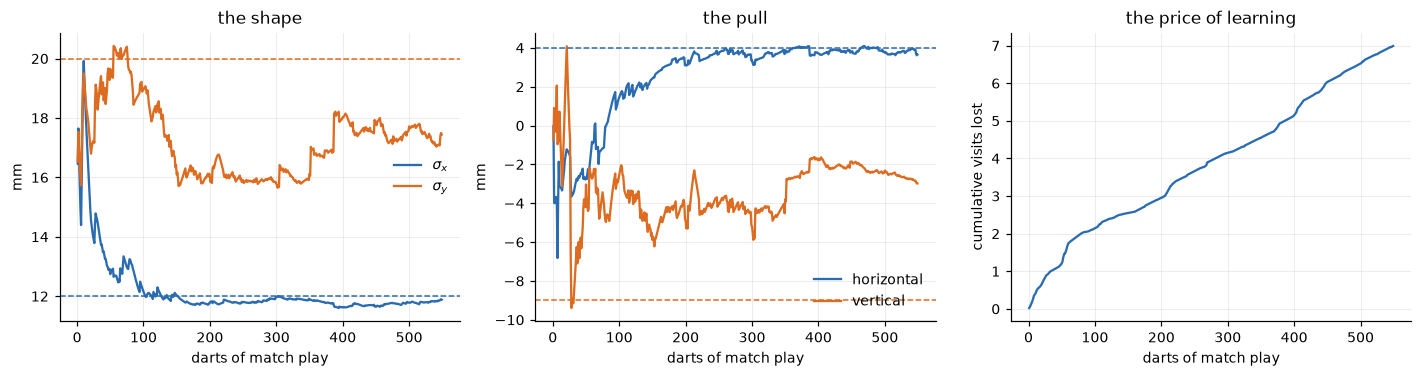

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
x = np.arange(1, len(hist) + 1)
axes[0].plot(x, hist.sigma_x, color='#2b6cb0', label=r'$\sigma_x$')
axes[0].plot(x, hist.sigma_y, color='#dd6b20', label=r'$\sigma_y$')
axes[0].axhline(12.0, color='#2b6cb0', ls='--', lw=1)
axes[0].axhline(20.0, color='#dd6b20', ls='--', lw=1)
axes[0].set_xlabel('darts of match play'); axes[0].set_ylabel('mm')
axes[0].set_title('the shape'); axes[0].legend()

axes[1].plot(x, hist.bias_x, color='#2b6cb0', label='horizontal')
axes[1].plot(x, hist.bias_y, color='#dd6b20', label='vertical')
axes[1].axhline(TRUE_B[0], color='#2b6cb0', ls='--', lw=1)
axes[1].axhline(TRUE_B[1], color='#dd6b20', ls='--', lw=1)
axes[1].set_xlabel('darts of match play'); axes[1].set_ylabel('mm')
axes[1].set_title('the pull'); axes[1].legend()

axes[2].plot(x, hist.value_loss.cumsum(), color='#2b6cb0')
axes[2].set_xlabel('darts of match play'); axes[2].set_ylabel('cumulative visits lost')
axes[2].set_title('the price of learning')
fig.tight_layout()

### A miss costs a hundred times what a hit does

Twenty legs of real play cost **456 ms a dart**, twenty times the 22 ms the benchmark above
promised. The benchmark is not wrong; it is measuring the wrong dart. It scores every throw
a 20, and a real leg is full of throws that score something else -- including nothing.

The likelihood of a dart is a sum of Gaussian density over every pixel of the board carrying
the observed score. A 20 is one bed: about 5,000 pixels. A **miss** is the entire non-scoring
board: 145,000. So a scoring dart costs 27 ms and a missed one **3.4 seconds**, and since a
leg contains plenty of misses the average is dragged up by a factor of twenty.

This is an implementation artefact rather than anything about the model, and it is worth
naming because the obvious fix does not work. Almost all of those 145,000 pixels are many
standard deviations from the dart and contribute nothing, so the sum could be truncated --
except that the pixel set is shared across the whole particle cloud, and the cloud spans
$\sigma$ from 3.5 mm to 46 mm. A single cutoff has to be sized for the widest particle, and
at eight standard deviations that is wider than the board. Truncating properly means giving
each band of particles its own pixel set, which is a real change rather than a constant.

Until then the honest number for live play is **half a second a dart**, not 22 ms. That is
still comfortably inside the gap between two throws, so the conclusion survives -- but with
a twentieth of the headroom the benchmark advertises.

## Tracking a player who changes

The grid assumed the player was fixed and sharpened forever. A pull is exactly what appears
when someone tires, and the filter has the natural hook for it: a small random walk on the
parameters each dart turns the estimator into a tracker.

There is a trap in the interface, worth showing rather than hiding. The parameters live in a
*transformed* space -- the spreads as logarithms, the bias in millimetres -- so a single
number for "the drift" means completely different things to each. A scalar 0.02 is a 2%
multiplicative wobble on the spread every dart, and two hundredths of a millimetre on the
pull: enormous for one, negligible for the other. Below, the player's pull grows steadily
through the session, and all three filters see the same darts.

,mean |error| over the last 200 darts
filter,
estimator (no drift),3.46
tracker (scalar 0.02),4.23
"tracker (sigma 0.002, bias 0.25 mm)",1.11


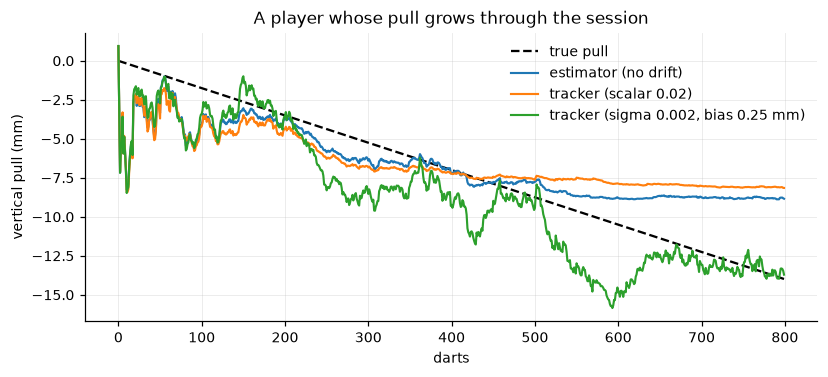

In [8]:
def drifting_sequence(n, seed=0):
    '''The pull grows steadily over the session, as a tiring player's would.'''
    L = np.linalg.cholesky(TRUE_S)
    rng = np.random.default_rng(seed)
    targets = [np.array([0.0, 103.0]), np.array([-80.0, -40.0]),
               np.array([0.0, 0.0]), np.array([100.0, 60.0])]
    out, truth = [], []
    for i in range(n):
        b = np.array([0.0, -14.0 * i / n])          # drifts from 0 to -14 mm
        t = targets[i % len(targets)]
        land = t + b + L @ rng.standard_normal(2)
        col = int(round(land[0] / MM)) + CENTRE
        row = int(round(land[1] / MM)) + CENTRE
        v = int(BOARD[row, col]) if 0 <= row < PX and 0 <= col < PX else 0
        out.append((t, v))
        truth.append(b[1])
    return out, np.array(truth)

drift_darts, truth_by = drifting_sequence(800, seed=7)
traces = {}
# drift must be given per parameter: the sigma components are logarithms
# and the bias components are millimetres, so one number cannot serve both
for label, drift in [('estimator (no drift)', 0.0),
                     ('tracker (scalar 0.02)', 0.02),
                     ('tracker (sigma 0.002, bias 0.25 mm)',
                      {'sigma': 0.002, 'bias': 0.25})]:
    pf = ParticleThrowPosterior(400, band='league', drift=drift, board=BOARD,
                                checkouts=CHECKOUTS, rng=np.random.default_rng(5))
    trace = []
    for t, v in drift_darts:
        pf.update(t, v, pixel=False)
        trace.append(pf.mean_bias()[1])
    traces[label] = np.array(trace)

fig, ax = plt.subplots(figsize=(7.6, 3.5))
ax.plot(truth_by, 'k--', lw=1.5, label='true pull')
for label, tr in traces.items():
    ax.plot(tr, lw=1.4, label=label)
ax.set_xlabel('darts'); ax.set_ylabel('vertical pull (mm)')
ax.set_title('A player whose pull grows through the session')
ax.legend()
fig.tight_layout()

tail = slice(-200, None)
pd.DataFrame([{'filter': k,
               'mean |error| over the last 200 darts': np.abs(v[tail] - truth_by[tail]).mean()}
              for k, v in traces.items()]).set_index('filter').round(2)

The trap is real, and it fires in the direction that would have gone unnoticed.

With a **scalar** drift of 0.02 the "tracker" is *worse than not modelling drift at all* --
4.23 mm of mean error against the estimator's 3.46. It is drowning the spread in a 2%
per-dart wobble while nudging the pull by two hundredths of a millimetre, which is the
opposite of what tracking a drifting pull requires.

Given per parameter -- 0.002 on the log-spreads, 0.25 mm on the bias -- it does what it was
supposed to: **1.11 mm**, about three times better than the plain estimator, and the trace
follows the true pull down through the session instead of lagging behind a running average
of it.

So the fix was not a bigger or smaller number but a *shaped* one, and the interface now
takes a dict so the question "how much drift?" cannot be answered without saying drift in
what.

## When to use which

**Use the grid** (`ThrowPosterior`) for analysis after the fact: it is exact up to its
discretisation, deterministic, and there is nothing to tune. Fifteen minutes to work through
a session's scoresheet is fine, and being able to plot a genuine posterior surface -- as
notebooks 12 and 13 do -- is worth the wait.

**Use the filter** (`ParticleThrowPosterior`) for anything live. It is a drop-in: same
`update`, same summaries, same `play_leg`. Three hundred particles gives the grid's answer
at about 22 ms a dart including the recommendation, which is forty-six darts a second
against the grid's not quite two, and it stays that fast when the belief is broad -- when a
grid is at its slowest and the player has had least advice.

**Reach for the filter sooner than the timings alone suggest**, because the grid's real
limit is dimensional rather than temporal. A fifth parameter multiplies its points by the
number of values that axis takes; the filter's cost does not move. That makes the tilt in
$\Sigma$ -- a grid dimension that would have cost a factor of five, on top of multiplying
the *solve* grid -- merely a constructor flag here.

### What is still open

* **Drift is a hook, not a calibration.** 0.25 mm a dart tracked this simulated player well.
  What a real player's pull actually does over an evening is unmeasured, and the right
  number can only come from a real session.
* **The solve grid is still the floor.** Twenty-five MDPs at nearly two minutes is an offline
  cost the filter does nothing about, and a genuinely continuous covariance would need
  interpolation between solved value functions rather than nearest-neighbour snapping.
* **The filter is stochastic.** Two runs on the same darts give slightly different answers,
  which is fine for advice and would be irritating in a published table. That is why the
  analysis notebooks keep the grid.
* **And it is all still simulated.** A filter that runs at forty-six darts a second is exactly what
  a real session needs, which makes the untested step more tempting and no less untested.